In [91]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score,
    balanced_accuracy_score,
    classification_report,
    mean_absolute_error,
    f1_score)
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, balanced_accuracy_score
import numpy as np

In [103]:
df = pd.read_csv("./data/df_final_janeiro_18.csv")
df

,Autoavaliacao_Saude,Idade,Sexo,Cor_Raca,Estado_Civil,Nivel_Instrucao,Total_Moradores,Qtd_Comodos,Qtd_Banheiros,Possui_Automovel,...,Diagnostico_Doenca_Cronica,Grau_Limite_Depressao,Grau_Limite_Doenca_Mental,Grau_Limite_DORT,Pratica_Exercicio,Horas_TV,Fuma,Freq_Alcool,Apoio_Familiar,Apoio_Amigos
0,3.0,55.0,2.0,1.0,1.0,1.0,6.0,5.0,2.0,2.0,...,1.0,2.0,2.0,1.0,1.0,3.0,3.0,2.0,3.0,0.0
1,2.0,19.0,2.0,4.0,4.0,1.0,4.0,4.0,1.0,2.0,...,2.0,2.0,2.0,2.0,2.0,6.0,1.0,2.0,3.0,2.0
2,3.0,45.0,2.0,2.0,4.0,1.0,8.0,8.0,4.0,2.0,...,2.0,2.0,2.0,2.0,2.0,2.0,3.0,3.0,1.0,1.0
3,3.0,58.0,2.0,2.0,3.0,1.0,1.0,1.0,0.0,2.0,...,2.0,2.0,2.0,2.0,1.0,1.0,3.0,1.0,1.0,0.0
4,2.0,28.0,2.0,4.0,4.0,2.0,2.0,2.0,1.0,2.0,...,2.0,2.0,2.0,2.0,1.0,2.0,3.0,1.0,3.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
90841,3.0,54.0,2.0,4.0,1.0,1.0,3.0,5.0,1.0,1.0,...,1.0,2.0,2.0,2.0,2.0,3.0,1.0,3.0,3.0,3.0
90842,2.0,44.0,1.0,4.0,2.0,1.0,2.0,5.0,1.0,1.0,...,2.0,2.0,2.0,2.0,2.0,6.0,1.0,3.0,2.0,2.0
90843,2.0,32.0,2.0,4.0,1.0,2.0,4.0,4.0,1.0,2.0,...,2.0,2.0,2.0,2.0,1.0,4.0,3.0,1.0,3.0,0.0
90844,3.0,54.0,1.0,4.0,1.0,1.0,3.0,10.0,3.0,1.0,...,1.0,1.0,2.0,1.0,1.0,2.0,3.0,1.0,1.0,3.0


In [104]:
# target = "Saude_Boa"
target = "Autoavaliacao_Saude"

In [81]:
df['Saude_Boa'] = df['Autoavaliacao_Saude'].map({
    1: 1,  # Muito boa
    2: 1,  # Boa
    3: 0,  # Regular
    4: 0,  # Ruim
    5: 0   # Muito ruim
})
df

,Autoavaliacao_Saude,Idade,Sexo,Cor_Raca,Estado_Civil,Nivel_Instrucao,Total_Moradores,Qtd_Comodos,Qtd_Banheiros,Possui_Automovel,...,Grau_Limite_Depressao,Grau_Limite_Doenca_Mental,Grau_Limite_DORT,Pratica_Exercicio,Horas_TV,Fuma,Freq_Alcool,Apoio_Familiar,Apoio_Amigos,Saude_Boa
0,3.0,55.0,2.0,1.0,1.0,1.0,6.0,5.0,2.0,2.0,...,2.0,2.0,1.0,1.0,3.0,3.0,2.0,3.0,0.0,0
1,2.0,19.0,2.0,4.0,4.0,1.0,4.0,4.0,1.0,2.0,...,2.0,2.0,2.0,2.0,6.0,1.0,2.0,3.0,2.0,1
2,3.0,45.0,2.0,2.0,4.0,1.0,8.0,8.0,4.0,2.0,...,2.0,2.0,2.0,2.0,2.0,3.0,3.0,1.0,1.0,0
3,3.0,58.0,2.0,2.0,3.0,1.0,1.0,1.0,0.0,2.0,...,2.0,2.0,2.0,1.0,1.0,3.0,1.0,1.0,0.0,0
4,2.0,28.0,2.0,4.0,4.0,2.0,2.0,2.0,1.0,2.0,...,2.0,2.0,2.0,1.0,2.0,3.0,1.0,3.0,0.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
90841,3.0,54.0,2.0,4.0,1.0,1.0,3.0,5.0,1.0,1.0,...,2.0,2.0,2.0,2.0,3.0,1.0,3.0,3.0,3.0,0
90842,2.0,44.0,1.0,4.0,2.0,1.0,2.0,5.0,1.0,1.0,...,2.0,2.0,2.0,2.0,6.0,1.0,3.0,2.0,2.0,1
90843,2.0,32.0,2.0,4.0,1.0,2.0,4.0,4.0,1.0,2.0,...,2.0,2.0,2.0,1.0,4.0,3.0,1.0,3.0,0.0,1
90844,3.0,54.0,1.0,4.0,1.0,1.0,3.0,10.0,3.0,1.0,...,1.0,2.0,1.0,1.0,2.0,3.0,1.0,1.0,3.0,0


Separando X e Y

In [107]:
X = df.drop(columns=[target, "Autoavaliacao_Saude"])
y = df[target]


Fazendo onehot encoding

In [108]:
cols_nominais = [
    'Sexo', 'Cor_Raca', 'Estado_Civil',
    'Possui_Automovel', 'Possui_Computador',
    'Acesso_Internet', 'Diagnostico_Doenca_Cronica',
    'Pratica_Exercicio', 'Fuma'
]
X = pd.get_dummies(X, columns=cols_nominais, drop_first=True)

In [109]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3, random_state=42, stratify=y)

Treinando Árvore de Decisão

In [86]:
model = DecisionTreeClassifier(
    max_depth=5,
    min_samples_leaf=200,
    class_weight='balanced',
    random_state=42
)

model.fit(X_train, y_train)


,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,200
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,'balanced'


In [87]:
y_pred_cont = model.predict(X_test)
y_pred = np.clip(np.round(y_pred_cont), 1, 5).astype(int)


In [88]:
y_pred = model.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


[[ 7010  3197]
 [ 4773 12274]]
              precision    recall  f1-score   support

           0       0.59      0.69      0.64     10207
           1       0.79      0.72      0.75     17047

    accuracy                           0.71     27254
   macro avg       0.69      0.70      0.70     27254
weighted avg       0.72      0.71      0.71     27254



In [89]:
importances = (
    pd.DataFrame({
        "feature": X.columns,
        "importance": model.feature_importances_
    })
    .sort_values("importance", ascending=False)
)

print(importances.head(20))


                           feature  importance
28  Diagnostico_Doenca_Cronica_2.0    0.491793
26           Possui_Computador_2.0    0.186519
6                     Freq_Cansaco    0.116075
0                            Idade    0.083473
29           Pratica_Exercicio_2.0    0.041684
8                   Freq_Depressao    0.030066
13                     Freq_Alcool    0.014110
1                  Nivel_Instrucao    0.013758
7                    Freq_Anedonia    0.008698
5              Freq_Problemas_Sono    0.008209
27             Acesso_Internet_2.0    0.005614
9            Grau_Limite_Depressao    0.000000
4                    Qtd_Banheiros    0.000000
3                      Qtd_Comodos    0.000000
10       Grau_Limite_Doenca_Mental    0.000000
2                  Total_Moradores    0.000000
15                    Apoio_Amigos    0.000000
14                  Apoio_Familiar    0.000000
12                        Horas_TV    0.000000
11                Grau_Limite_DORT    0.000000


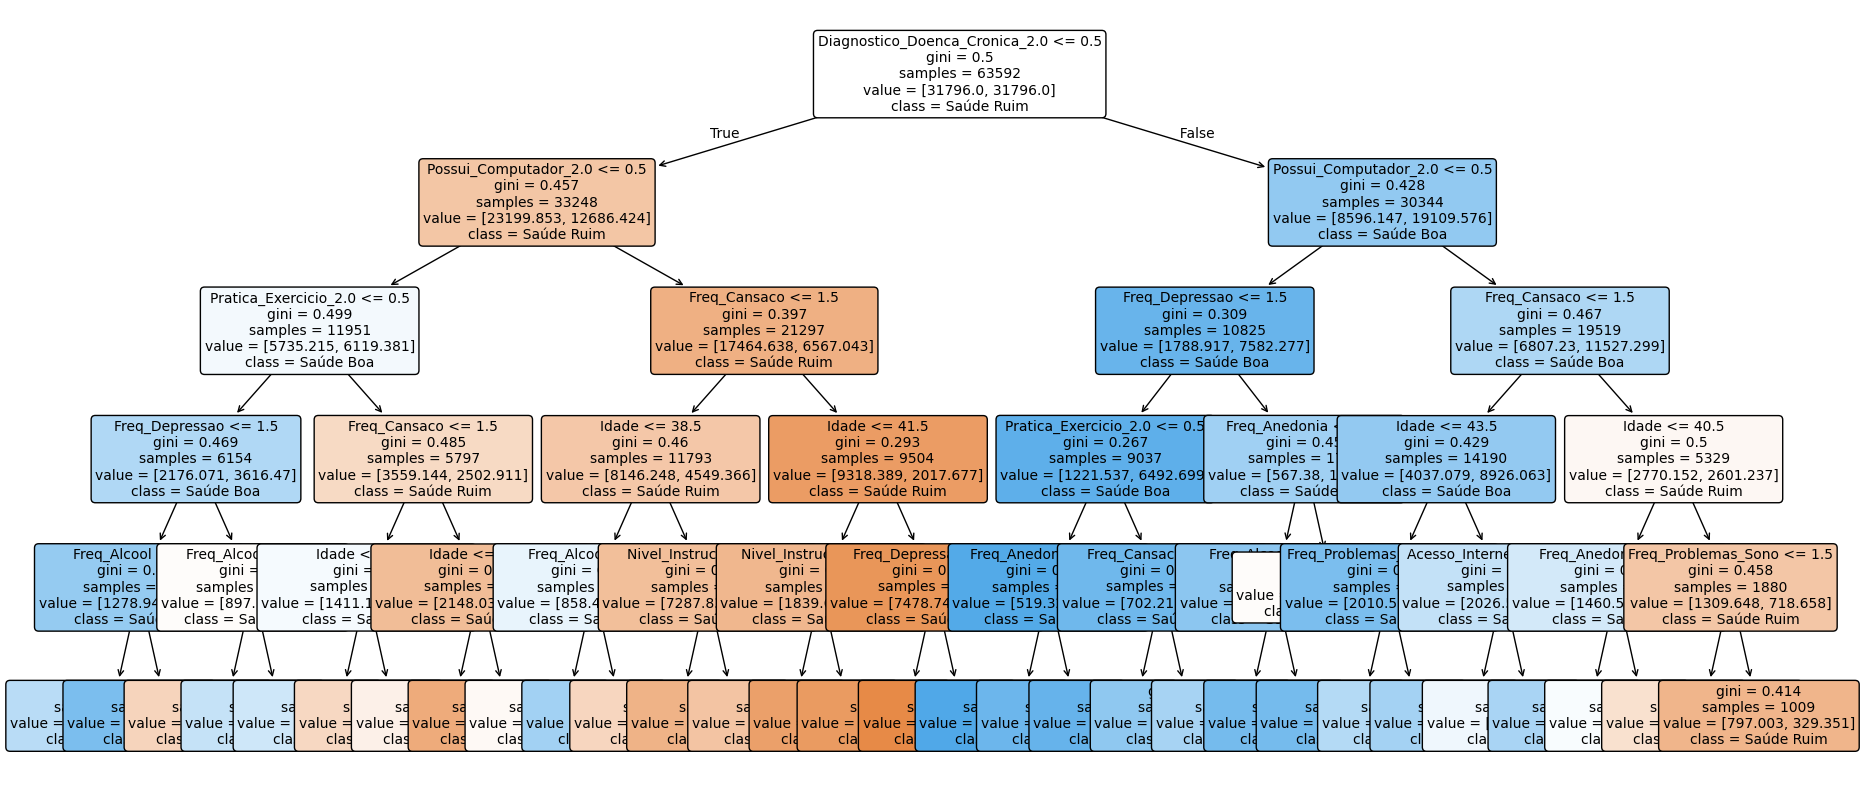

In [90]:
plt.figure(figsize=(22, 10))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Saúde Ruim", "Saúde Boa"], 
    filled=True,
    rounded=True,
    fontsize=10
)

plt.show()
